## 1.Download and load the Breast Cancer Wisconsin (Diagnostic) dataset.


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


The Breast Cancer Wisconsin (Diagnostic) dataset was successfully downloaded from the UCI Machine Learning Repository and loaded into a Pandas DataFrame. The dataset contains information about tumor characteristics, which will be used to classify tumors as benign or malignant.

## 2.Perform exploratory data analysis and data preprocessing.


In [2]:
import pandas as pd

columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv("wdbc.data", header=None, names=columns)

print(df.head())

         ID Diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [3]:
print("Shape of Dataset:", df.shape)

print("\nInformation:")
print(df.info())

Shape of Dataset: (569, 32)

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null 

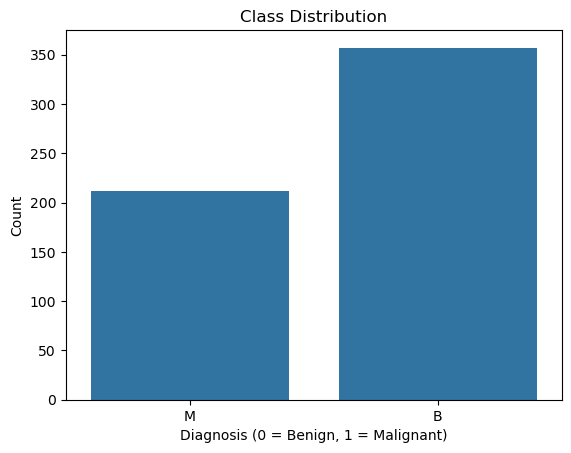

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Diagnosis", data=df)
plt.title("Class Distribution")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Count")
plt.show()


The exploratory data analysis showed that the dataset consists of numerical features describing the characteristics of cell nuclei. The dataset has 569 samples and 32 columns, including the ID, diagnosis label, and 30 predictor features. The statistical summary indicates that the features have different value ranges, suggesting that feature scaling will be necessary before training the models.

## 3.Check for missing values and prepare the dataset for classification.


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())




Missing Values:
ID                         0
Diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [6]:

print("Duplicate Rows:", df.duplicated().sum()) 

Duplicate Rows: 0


In [7]:
df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})

X = df.drop(["ID", "Diagnosis"], axis=1)
y = df["Diagnosis"]

print(X.shape)
print(y.shape)

(569, 30)
(569,)


The dataset does not contain any missing values, indicating that it is complete and suitable for model training. The diagnosis column was encoded into numerical values (Malignant = 1, Benign = 0), and the ID column was removed as it does not contribute to the prediction process.

## 4.Split the dataset into training and testing sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


The dataset was divided into training and testing sets using an 80:20 ratio. This ensures that the models are trained on one portion of the data and evaluated on unseen data, providing a fair assessment of their performance.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Feature scaling was performed using StandardScaler to standardize all numerical features. This preprocessing step is essential because the features have different ranges, and algorithms such as KNN rely on distance calculations, while Logistic Regression also benefits from normalized input features.

## 5.Train a Logistic Regression classifier.


In [10]:
lr = LogisticRegression(max_iter=500)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)


The Logistic Regression model was successfully trained using the standardized training data. The model learned the relationship between the input features and the diagnosis labels, enabling it to classify tumors as benign or malignant.

## 6.Train a K Nearest Neighbors (KNN) classifier.


In [11]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

c:\Users\Albin Thomas\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Albin Thomas\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Albin Thomas\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Albin Thomas\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~


The K-Nearest Neighbors (KNN) classifier was trained using the scaled training data with the selected value of K. The model classifies new samples based on the majority class among their nearest neighboring data points.

## 7.Evaluate both classifiers using:
### Accuracy
### Precision
### Recall
### F1 Score
### Confusion Matrix


In [12]:
def evaluate_model(y_test, predictions):

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    cm = confusion_matrix(y_test, predictions)

    return accuracy, precision, recall, f1, cm

In [13]:
lr_accuracy, lr_precision, lr_recall, lr_f1, lr_cm = evaluate_model(
    y_test,
    lr_pred
)

print("Logistic Regression Results")

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

print("\nClassification Report")
print(classification_report(y_test, lr_pred))

Logistic Regression Results
Accuracy : 0.9649122807017544
Precision: 0.975
Recall   : 0.9285714285714286
F1 Score : 0.9512195121951219

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



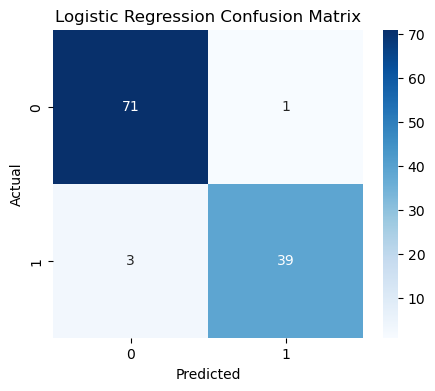

In [14]:
plt.figure(figsize=(5,4))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
knn_accuracy, knn_precision, knn_recall, knn_f1, knn_cm = evaluate_model(
    y_test,
    knn_pred
)

print("KNN Results")

print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

print("\nClassification Report")
print(classification_report(y_test, knn_pred))

KNN Results
Accuracy : 0.956140350877193
Precision: 0.9743589743589743
Recall   : 0.9047619047619048
F1 Score : 0.9382716049382716

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



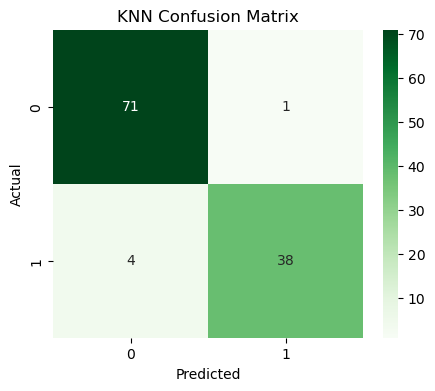

In [16]:
plt.figure(figsize=(5,4))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Both classifiers were evaluated using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix. These evaluation metrics provide a comprehensive assessment of each model's classification performance and ability to correctly identify benign and malignant tumors.

## 8.Compare the performance of the two classifiers using a comparison table.


In [17]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "KNN"
    ],

    "Accuracy":[
        lr_accuracy,
        knn_accuracy
    ],

    "Precision":[
        lr_precision,
        knn_precision
    ],

    "Recall":[
        lr_recall,
        knn_recall
    ],

    "F1 Score":[
        lr_f1,
        knn_f1
    ]

})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.964912   0.975000  0.928571  0.951220
1                  KNN  0.956140   0.974359  0.904762  0.938272


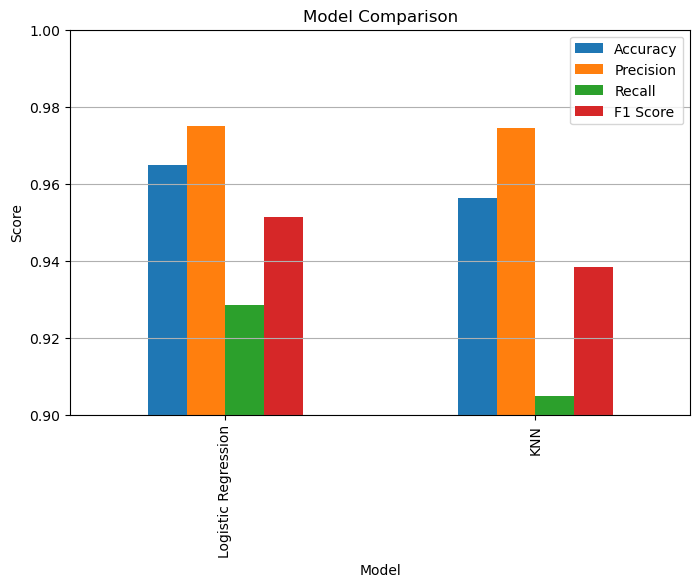

In [18]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Score")
plt.title("Model Comparison")
plt.ylim(0.9,1.0)
plt.grid(axis="y")
plt.show()

## 9.Interpret the results and comment on the better-performing classifier for the given dataset.


Both Logistic Regression and K-Nearest Neighbors (KNN) classifiers performed well on the Breast Cancer Wisconsin (Diagnostic) dataset, achieving classification accuracies above 95%. Logistic Regression slightly outperformed KNN in terms of Accuracy (96.49% vs. 95.61%), Recall (92.85% vs. 90.47%), and F1-Score (95.12% vs. 93.82%), while both models achieved nearly identical Precision values (97.50% and 97.43%).

The confusion matrices further show that Logistic Regression made only 4 incorrect predictions, whereas KNN made 5 incorrect predictions. This indicates that Logistic Regression classified the samples more accurately and identified malignant cases more effectively.

Based on the experimental results, **Logistic Regression is the better-performing classifier for the Breast Cancer Wisconsin (Diagnostic) dataset** because it achieved higher overall evaluation metrics and fewer misclassifications. Therefore, Logistic Regression is recommended as the most suitable classifier for this dataset.